In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mernaaziz","key":"eb25defac60f8f7441c7b814c9a7486c"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("drsaeedmohsen/ucihar-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ucihar-dataset' dataset.
Path to dataset files: /kaggle/input/ucihar-dataset


In [4]:
import os

print(os.listdir(path))

['UCI-HAR Dataset']


In [5]:
print(os.listdir(path + "/UCI-HAR Dataset"))

['activity_labels.txt', 'README.txt', 'features_info.txt', 'features.txt', 'test', 'train']


In [6]:
print(os.listdir(path + "/UCI-HAR Dataset/train"))

['X_train.txt', 'Inertial Signals', 'subject_train.txt', 'y_train.txt']


In [7]:
import pandas as pd

file_path = path + "/UCI-HAR Dataset/train/X_train.txt"

df = pd.read_csv(file_path, delim_whitespace=True, header=None)
df.head()

/tmp/ipykernel_3019/797909614.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [8]:
import numpy as np
import os

base = path + "/UCI-HAR Dataset"

signals = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

def load_signals(folder):
    data = []
    for signal in signals:
        file = f"{base}/{folder}/Inertial Signals/{signal}_{folder}.txt"
        loaded = np.loadtxt(file)
        data.append(loaded)
    return np.transpose(np.array(data), (1, 2, 0))

In [9]:
X_train = load_signals("train")
X_test = load_signals("test")

print(X_train.shape)  # (7352, 128, 9)
print(X_test.shape)

(7352, 128, 9)
(2947, 128, 9)


In [10]:
y_train = np.loadtxt(base + "/train/y_train.txt") - 1
y_test = np.loadtxt(base + "/test/y_test.txt") - 1

In [11]:
X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()

ONE-HOT ENCODING

In [12]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

CNN-LSTM ARCHITECTURE

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Bidirectional

model = Sequential()

# 🔹 CNN Block 1
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(128, 9)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# 🔹 CNN Block 2
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# 🔹 LSTM (Bidirectional = 🔥 boost)
model.add(Bidirectional(LSTM(100, return_sequences=False)))

# 🔹 Dense layers
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       183,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,170 (903.01 KB)

 Trainable params: 230,786 (901.51 KB)

 Non-trainable params: 384 (1.50 KB)

Training

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 157ms/step - accuracy: 0.8598 - loss: 0.3709 - val_accuracy: 0.7947 - val_loss: 0.5237
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step - accuracy: 0.9457 - loss: 0.1422 - val_accuracy: 0.8965 - val_loss: 0.2900
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.9509 - loss: 0.1201 - val_accuracy: 0.8904 - val_loss: 0.3781
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.9497 - loss: 0.1262 - val_accuracy: 0.9131 - val_loss: 0.2448
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9501 - loss: 0.1141 - val_accuracy: 0.9121 - val_loss: 0.3262
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9520 - loss: 0.1081 - val_accuracy: 0.9247 - val_loss: 0.2270
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.9493 - loss: 0.1253 - val_accuracy: 0.9281 - val_loss: 0.2968
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9554 - loss: 0

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.9680 - loss: 0.0754 - val_accuracy: 0.9355 - val_loss: 0.3061
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.9630 - loss: 0.0831 - val_accuracy: 0.9036 - val_loss: 0.3828
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 152ms/step - accuracy: 0.9627 - loss: 0.0808 - val_accuracy: 0.9325 - val_loss: 0.2497
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.9697 - loss: 0.0689 - val_accuracy: 0.9396 - val_loss: 0.2443
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.9699 - loss: 0.0651 - val_accuracy: 0.9281 - val_loss: 0.3527
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9710 - loss: 0.0691 - val_accuracy: 0.9298 - val_loss: 0.2493
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.9713 - loss: 0.0622 - val_accuracy: 0.9389 - val_loss: 0.2712
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.9705 - loss: 0

Evaluate

In [16]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9396 - loss: 0.2443
Accuracy: 0.9395995736122131


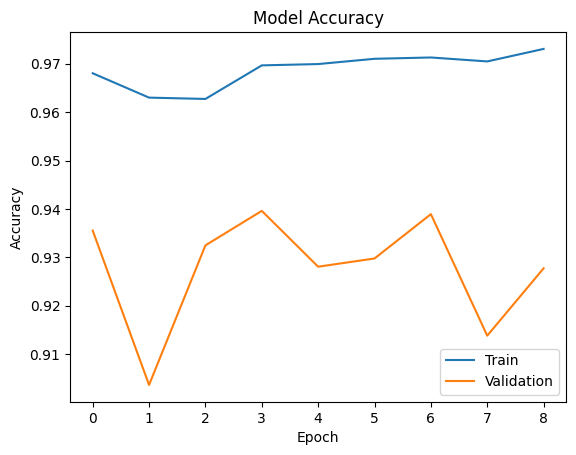

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

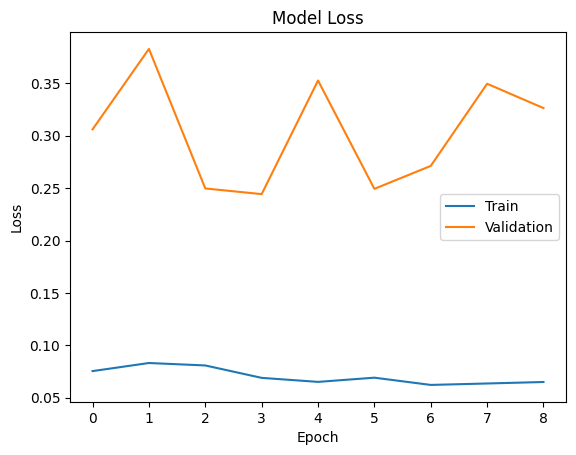

In [18]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()